In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score

In [4]:
MODEL_START_SEASON = 2010
VALIDATION_SEASON = 2024
TEST_SEASON = 2025
RANDOM_STATE = 42

In [5]:
df = pd.read_csv('../data/processed/model_dataset_v2.csv', parse_dates=['gameday'],)

In [6]:
df = (
    df
    .sort_values(['gameday', 'game_id'])
    .reset_index(drop=True)
)
df.shape

(4617, 80)

In [7]:
feature_columns = [
    'pregame_off_epa_blended',
    'pregame_off_success_rate_blended',
    'pregame_pass_epa_blended',
    'pregame_rush_epa_blended',
    'pregame_def_epa_allowed_blended',
    'pregame_def_success_rate_allowed_blended',
    'off_epa_last3',
    'off_success_rate_last3',
    'pass_epa_last3',
    'rush_epa_last3',
    'def_epa_allowed_last3',
    'def_success_rate_allowed_last3',
    'off_epa_last5',
    'off_success_rate_last5',
    'pass_epa_last5',
    'rush_epa_last5',
    'def_epa_allowed_last5',
    'def_success_rate_allowed_last5',
    'off_epa_ewm',
    'off_success_rate_ewm',
    'pass_epa_ewm',
    'rush_epa_ewm',
    'def_epa_allowed_ewm',
    'def_success_rate_allowed_ewm',
    'pregame_elo',
    'pregame_sos',
    'rest_days',
    'short_rest',
    'prior_games',
    'pregame_turnovers',
    'pregame_takeaways',
    'pregame_off_sack_rate',
    'pregame_def_sack_rate',
    'pregame_qb_epa',
    'pregame_qb_epa_last5',
    'pregame_qb_success_rate'
]

features = [
    f"{side}_{column}"
    for side in ["home", "away"]
    for column in feature_columns
] + ["neutral_site"]

target = 'home_win'

In [8]:
train = df[df['season'].between(MODEL_START_SEASON, 2023)].copy()
val = df[df['season'] == VALIDATION_SEASON].copy()
test = df[df['season'] == TEST_SEASON].copy()

X_train = train[features]
y_train = train[target]

X_val = val[features]
y_val = val[target]

X_test = test[features]
y_test = test[target]

print('Training Games:', len(train))
print('Validation Games:', len(val))
print('Test Games:', len(test))

Training Games: 3781
Validation Games: 285
Test Games: 284


In [9]:
def evaluate_probabilities(
        model_name,
        y_true,
        probabilities,
        evaluation_period=None,
):
    predictions = (probabilities >= 0.5).astype(int)

    return {
        'model': model_name,
        'period': evaluation_period,
        'accuracy': accuracy_score(y_true, predictions),
        'log_loss': log_loss(y_true, probabilities),
        'brier_score': brier_score_loss(y_true, probabilities),
        'roc_auc': roc_auc_score(y_true, probabilities),
        }

In [10]:
training_home_win_rate = y_train.mean()

baseline_val_prob = np.full(
    len(y_val),
    training_home_win_rate,
)

baseline_result = evaluate_probabilities(
    model_name='Baseline',
    y_true=y_val,
    probabilities=baseline_val_prob,
    evaluation_period='2024',
)

pd.DataFrame([baseline_result]).head()

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Baseline,2024,0.547368,0.688958,0.247907,0.5


In [11]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

In [12]:
random_forest_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

In [13]:
gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    l2_regularization=1,
    early_stopping=False,
    random_state=RANDOM_STATE,
)

In [14]:
initial_models = {
    "Logistic Regression V2": logistic_model,
    "Random Forest": random_forest_model,
    "Histogram Gradient Boosting": gradient_boosting_model,
}

fitted_initial_models = {}
validation_probabilities = {}
validation_rows = [baseline_result]

for model_name, estimator in initial_models.items():
    fitted_model = clone(estimator)
    fitted_model.fit(X_train, y_train)

    probabilities = fitted_model.predict_proba(X_val)[:, 1]

    fitted_initial_models[model_name] = fitted_model
    validation_probabilities[model_name] = probabilities

    validation_rows.append(
        evaluate_probabilities(
            model_name=model_name,
            y_true=y_val,
            probabilities=probabilities,
            evaluation_period='2024',
        )
    )

In [15]:
initial_results = (
    pd.DataFrame(validation_rows)  
    .sort_values(['log_loss', 'brier_score'], ascending=True)
    .reset_index(drop=True)
)

initial_results


,model,period,accuracy,log_loss,brier_score,roc_auc
0,Random Forest,2024,0.677193,0.612427,0.211144,0.733502
1,Logistic Regression V2,2024,0.652632,0.622125,0.216819,0.709253
2,Histogram Gradient Boosting,2024,0.652632,0.634156,0.220978,0.698022
3,Baseline,2024,0.547368,0.688958,0.247907,0.500000


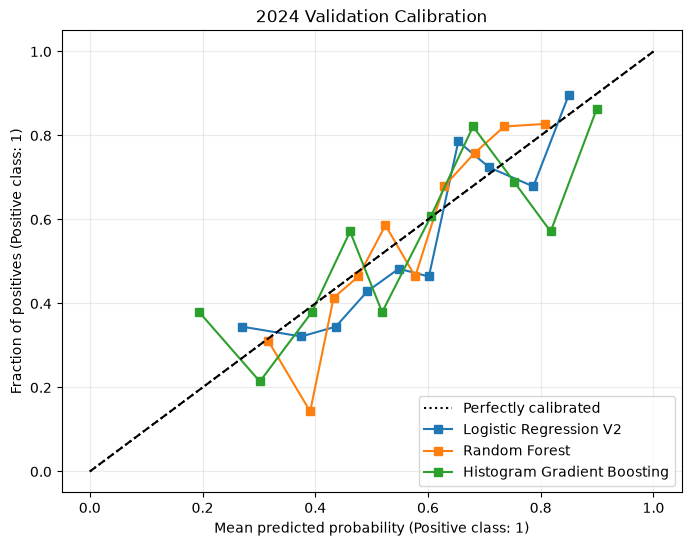

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in validation_probabilities.items():
    CalibrationDisplay.from_predictions(
        y_val,
        probabilities,
        n_bins=10,
        strategy='quantile',
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='black',
    label='Perfect calibration'
)

ax.set_title('2024 Validation Calibration')
ax.grid(alpha=0.25)
plt.show()

In [17]:
v1_df = pd.read_csv('../data/processed/model_dataset_v1.csv')
v1_artifact = joblib.load('../models/logistic_regression_v1.joblib')

v1_features = v1_artifact['features']
v1_model = v1_artifact['model']

v1_val = v1_df[v1_df['season'] == 2024].copy()

common_game_ids = sorted(
    set(v1_val['game_id'])
    & set(val['game_id'])
)

v1_common = (v1_val[v1_val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))
v2_common = (val[val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))


In [18]:
v1_common_prob = v1_model.predict_proba(v1_common[v1_features])[:, 1]

v2_common_prob = fitted_initial_models[
    'Logistic Regression V2'
    ].predict_proba(v2_common[features])[:, 1]

In [19]:
v1_v2_results = pd.DataFrame([
    evaluate_probabilities(
        'Logistic Regression V1',
        v1_common['home_win'],
        v1_common_prob,
        '2024 shared games',
    ),
    evaluate_probabilities(
        'Logistic Regression V2',
        v2_common['home_win'],
        v2_common_prob,
        '2024 shared games',
    ),
])

v1_v2_results



,model,period,accuracy,log_loss,brier_score,roc_auc
0,Logistic Regression V1,2024 shared games,0.672862,0.622797,0.215553,0.727642
1,Logistic Regression V2,2024 shared games,0.654275,0.623086,0.217162,0.709455


In [20]:
development = df[df['season'].between(MODEL_START_SEASON, 2024)].copy()

CV_SEASONS = [2020, 2021, 2022, 2023, 2024]

In [21]:
def temporal_parameter_search(
        model_name,
        estimator,
        parameter_grid,
        data,
        features,
        target,
        validation_seasons,
):
    search_rows = []

    for parameters in ParameterGrid(parameter_grid):
       fold_metrics = []

       for validation_season in validation_seasons:
           fold_train = data[data['season'] < validation_season]
           fold_val = data[data['season'] == validation_season]

           fold_model = clone(estimator).set_params(**parameters)
           fold_model.fit(fold_train[features], fold_train[target])
           fold_prob = fold_model.predict_proba(fold_val[features])[:, 1]

           fold_metrics.append(
               evaluate_probabilities(
                   model_name=model_name,
                   y_true=fold_val[target],
                   probabilities=fold_prob,
                   evaluation_period=validation_season,
               )
           )

       fold_results = pd.DataFrame(fold_metrics)

       search_rows.append({
           'model': model_name,
           'parameters': parameters,
           'mean_log_loss': fold_results['log_loss'].mean(),
           'std_log_loss': fold_results['log_loss'].std(),
           'mean_brier': fold_results['brier_score'].mean(),
           'mean_accuracy': fold_results['accuracy'].mean(),
           'mean_roc_auc': fold_results['roc_auc'].mean(),
       })

    return (
        pd.DataFrame(search_rows)
        .sort_values(['mean_log_loss', 'mean_brier'], ascending=True,
    ).reset_index(drop=True)
    )


In [22]:
logistic_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
}
logistic_search = temporal_parameter_search(
    model_name='Logistic Regression',
    estimator=logistic_model,
    parameter_grid=logistic_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

logistic_search

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Logistic Regression,{'classifier__C': 0.01},0.637576,0.023816,0.223272,0.639139,0.688315
1,Logistic Regression,{'classifier__C': 0.1},0.642073,0.025377,0.225195,0.637871,0.682367
2,Logistic Regression,{'classifier__C': 1.0},0.644416,0.026301,0.226206,0.635877,0.678810
3,Logistic Regression,{'classifier__C': 10.0},0.645086,0.026634,0.226502,0.633033,0.678226


In [23]:
random_forest_grid = {
    'model__max_depth': [4, 8, None],
    'model__min_samples_leaf': [5, 15],
    'model__max_features': ['sqrt', 0.5],
}

random_forest_search = temporal_parameter_search(
    model_name='Random Forest',
    estimator=random_forest_model,
    parameter_grid=random_forest_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

random_forest_search

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.632565,0.020410,0.221264,0.638941,0.694644
1,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.633566,0.020764,0.221741,0.636057,0.692986
2,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.633824,0.021179,0.221756,0.643796,0.691875
3,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.634097,0.020120,0.221959,0.638076,0.691899
4,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.634279,0.019215,0.222057,0.636057,0.692113
5,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.634730,0.022467,0.222077,0.642353,0.689662
6,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.635156,0.021074,0.222341,0.638805,0.689767
7,Random Forest,"{'model__max_depth': 4, 'model__max_features':...",0.635400,0.018671,0.222405,0.639574,0.691418
8,Random Forest,"{'model__max_depth': 4, 'model__max_features':...",0.635418,0.019625,0.222393,0.638827,0.691682
9,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.635858,0.023003,0.222433,0.638182,0.689706


In [24]:
gradient_boosting_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_leaf_nodes': [7, 15],
    'min_samples_leaf': [10, 20],
    'l2_regularization': [0.0, 1.0],
}

gradient_boosting_search = temporal_parameter_search(
    model_name='Histogram Gradient Boosting',
    estimator=gradient_boosting_model,
    parameter_grid=gradient_boosting_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

gradient_boosting_search.head()

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.633801,0.028344,0.221851,0.644167,0.690304
1,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.635564,0.025871,0.222549,0.637448,0.688873
2,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.636685,0.029906,0.222984,0.636111,0.687326
3,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.637575,0.027733,0.223492,0.640359,0.684635
4,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.640500,0.027493,0.224700,0.635358,0.680942


In [25]:
best_logistic_params = logistic_search.iloc[0]['parameters']
best_random_forest_params = random_forest_search.iloc[0]['parameters']
best_gradient_boosting_params = gradient_boosting_search.iloc[0]['parameters']

tuned_models = {
    'Logistic Regression': (
        clone(logistic_model)
        .set_params(**best_logistic_params)
    ),
    'Random Forest': (
        clone(random_forest_model)
        .set_params(**best_random_forest_params)
    ),
    'Histogram Gradient Boosting': (
        clone(gradient_boosting_model)
        .set_params(**best_gradient_boosting_params)
    ),
}

cv_winners = pd.concat([
    logistic_search.head(1),
    random_forest_search.head(1),
    gradient_boosting_search.head(1),
    ], ignore_index=True).sort_values(['mean_log_loss', 'mean_brier']
    )

cv_winners

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
1,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.632565,0.020410,0.221264,0.638941,0.694644
2,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.633801,0.028344,0.221851,0.644167,0.690304
0,Logistic Regression,{'classifier__C': 0.01},0.637576,0.023816,0.223272,0.639139,0.688315


In [26]:
def make_temporal_oof_predictions(
        model_name,
        estimator,
        data,
        features,
        target,
        validation_seasons,
):
    prediction_frames = []

    for validation_season in validation_seasons:
        fold_train = data[data['season'] < validation_season]

        fold_val = data[data['season'] == validation_season].copy()

        fold_model = clone(estimator)

        fold_model.fit(fold_train[features], fold_train[target])

        fold_val['predicted_probability'] = (
            fold_model.predict_proba(fold_val[features])[:, 1]
        )

        fold_val['model'] = model_name

        prediction_frames.append(fold_val[[
            'season',
            'week',
            'game_id',
            'home_team',
            'away_team',
            target,
            'predicted_probability',
            'model'
        ]]
        )
    return pd.concat(prediction_frames, ignore_index=True)

In [27]:
oof_predictions = pd.concat([
    make_temporal_oof_predictions(
        model_name,
        estimator,
        development,
        features,
        target,
        CV_SEASONS,
    )
    for model_name, estimator in tuned_models.items()], ignore_index=True)

In [28]:
oof_results = pd.DataFrame([
    evaluate_probabilities(
        model_name=model_name,
        y_true=model_predictions[target],
        probabilities=model_predictions['predicted_probability'],
        evaluation_period='2020-2024 temporal OOF',
    )
    for model_name, model_predictions in oof_predictions.groupby('model')
    ]).sort_values(['log_loss', 'brier_score'])

oof_results

,model,period,accuracy,log_loss,brier_score,roc_auc
2,Random Forest,2020-2024 temporal OOF,0.638889,0.632709,0.221329,0.693950
0,Histogram Gradient Boosting,2020-2024 temporal OOF,0.643875,0.634023,0.221952,0.690770
1,Logistic Regression,2020-2024 temporal OOF,0.638889,0.637858,0.223409,0.687882


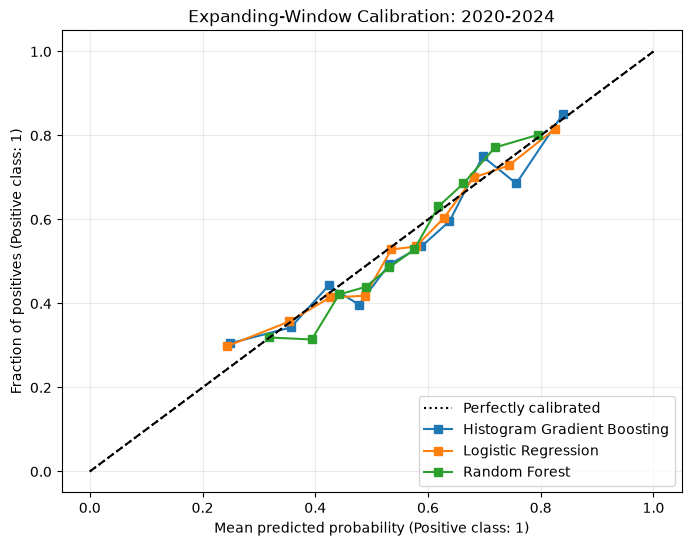

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model_predictions in oof_predictions.groupby('model'):
    CalibrationDisplay.from_predictions(
        model_predictions[target],
        model_predictions['predicted_probability'],
        n_bins=10,
        strategy='quantile',
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='black',
)
ax.set_title('Expanding-Window Calibration: 2020-2024')
ax.grid(alpha=0.25)
plt.show()


In [30]:
season_results = pd.DataFrame([
    evaluate_probabilities(
        model_name=model_name,
        y_true=season_data[target],
        probabilities=season_data['predicted_probability'],
        evaluation_period=season,
    )
    for (model_name, season), season_data
    in oof_predictions.groupby(['model', 'season'])
])
season_results.sort_values(
    ['period', 'log_loss']
    )

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Histogram Gradient Boosting,2020,0.675373,0.612270,0.212192,0.736077
5,Logistic Regression,2020,0.660448,0.613386,0.211492,0.737859
10,Random Forest,2020,0.645522,0.620705,0.215898,0.736912
11,Random Forest,2021,0.602113,0.645952,0.227685,0.675406
1,Histogram Gradient Boosting,2021,0.637324,0.655440,0.230572,0.671731
6,Logistic Regression,2021,0.619718,0.662672,0.234142,0.659566
12,Random Forest,2022,0.638298,0.627692,0.219049,0.691906
7,Logistic Regression,2022,0.641844,0.634085,0.221960,0.682275
2,Histogram Gradient Boosting,2022,0.606383,0.644654,0.226413,0.667828
13,Random Forest,2023,0.610526,0.659899,0.234095,0.629383


## Final model decision

Selected model: Histogram Gradient Boosting

Selected hyperparameters: 
12 Regularization = 0.0
Learning Rate = 0.03
Max Leaf Nodes = 7 
Minimum Samples Per Leaf = 20

Primary selection evidence:
Histogram gradient boosting achived the highest mean CV accuracy of 64.42% along with the highest accuracy in 3 of the 5 validation seasons. The mean CV was 0.6338 and the mean Brier score was       0.2218, slightly worse than the Random Forest model. This choice prioritizes the slightly higher winner-prediction accuracy.

The model and all hyperparameters were selected using
expanding validation through 2024. The 2025 season was not
used to select the final architecture.

chosen_model_name